##### ***序列到序列（seq2seq）***
###### 本节将遵循编码器-解码器架构的设计原则，RNN编码器将变长序列作为输入将其转换为固定形状的隐状态。解码器将基于输入和编码信息生成输出序列。
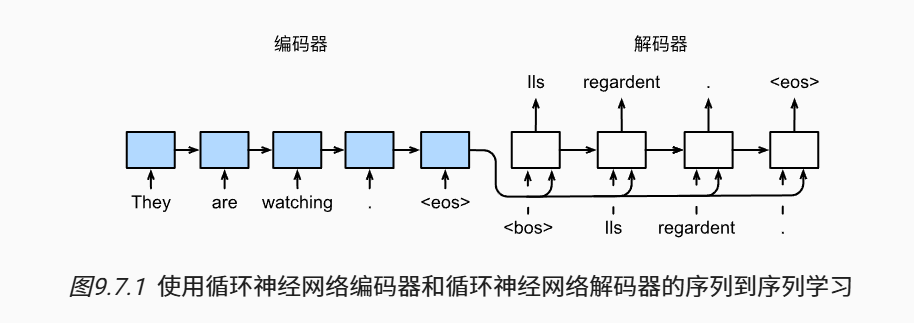

In [26]:
import collections
import torch
import math
from torch import nn
from d2l import torch as d2l

##### ***编码器***
###### 从技术上来讲，编码器将长度可变的输入序列转换为形状固定的上下文变量c，并将输入序列的信息在该上下文变量中进行编码，我们可以使用RNN来设计编码器。
###### 考虑一个序列组成的样本，假设输入序列是$x_1,\cdots,x_T$，其中$x_t$是输入文本序列中的第$t$个词元。在时间步$t$，循环神经网络将词元$x_t$的输入特征向量$x_t$和$h_{t-1}$作为输入，输出隐藏状态$h_t$。可以用一个函数来描述神经网络的循环层所做的变换：
$$h_t = f(x_t, h_{t-1})$$
###### 编码器通过选定的函数q，将所有时间步的隐状态转换为上下文变量：
$$c = q(h_1, \cdots, h_T)$$
###### 简单的做法是直接选择最后一个时间步的隐状态作为上下文变量。<br>目前为止我们选择使用单向RNN来设计编码器，其中隐状态只依赖于当前时间步和之前的子序列和隐状态，不过我们也可使用双向RNN。接着我们使用嵌入层（embedding layer）将输入序列转换为词元的特征向量表示，嵌入层的权重是一个矩阵，其是一个（vocab_size, embed_size）形状的矩阵，其中embed_size是特征向量的维度。

In [27]:
class Seq2SeqEncoder(d2l.Encoder):
    """序列到序列编码器"""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0, **kwargs):
        super(Seq2SeqEncoder, self).__init__(**kwargs)
        # 嵌入层
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers, dropout=dropout)
    
    def forward(self, X, *args):
        # X的形状是(batch_size, num_steps, embed_size)
        X = self.embedding(X)
        # 在循环神经网络模型中，第一个轴对应于时间步
        X = X.permute(1, 0, 2) # 转置
        # 如果未提及状态，则默认为0
        outputs, state = self.rnn(X)
        # outputs 输出的形状是(num_steps, batch_size, num_hiddens)
        # state 输出的形状是(num_layers, batch_size, num_hiddens)
        return outputs, state


In [28]:
encoder = Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
encoder.eval()
X = torch.zeros((4, 7), dtype=torch.long)
outputs, state = encoder(X)
print(outputs.shape)
print(state.shape)

torch.Size([7, 4, 16])
torch.Size([2, 4, 16])


##### ***解码器***
###### 正如上文所说，编码器输出的上下文变量c对整个输入序列$x_1,...,x_t$进行编码。来自训练数据集的输出序列$y_1,...,y_{t'}$，对于每个时间步$t'$（这里的时间步与输入序列或编码器的时间步t不同），解码器输出$y_{t'}$的概率取决于先前的输出子序列$y_1,...,y_{t'-1}$和上下文变量c，即$P(y_{t'}|y_1,\cdots,y_{t'-1}, c)$。而这种形式的公式与RNN十分相似，所以我们可以使用另一个RNN作为解码器。在输出序列上任意的时间步都由上一个时间步的输出的上下文变量作为输入，并且将隐状态也相应变换。因此可得到：
$$s_{t'} = g(y_{t'-1}, c, s_{t'-1}).$$
###### 获取到隐状态之后，我们就可以使用输出层和softmax来计算$P(y_{t'}|y_1,\cdots,y_{t'-1}, c)$。并且在具体实现中，我们直接使用编码器的最后一个时间步的隐状态来初始化解码器的隐状态，这就要求编码器和解码器具有相同数量的层和隐藏单元，且为了进一步的包含经过编码的序列信息，我们将上下文变量在所有时间步与解码器的输入进行拼接（concatenate），为了预测输出词元的概率分布，在循环神经网络解码器的最后一层使用全连接层来变换隐状态。

In [29]:
class Seq2SeqDecoder(d2l.Decoder):
    """用于序列到序列学习的循环神经网络解码器"""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0, **kwargs):
        super(Seq2SeqDecoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers, dropout=dropout) # 每一个时间步都要与上下文变量拼接
        self.dense = nn.Linear(num_hiddens, vocab_size)
    
    def init_state(self, encoder_outputs, *args):
        return encoder_outputs[1]

    def forward(self, X, state):
        # 输出X的形状：(batch_size, num_steps, embed_size)
        X= self.embedding(X).permute(1, 0, 2)
        # 广播context，使其具有与X相同的num_steps
        context = state[-1].repeat(X.shape[0], 1, 1) # 每个时间步都要加上上下文变量
        X_and_context = torch.cat((X, context), dim=2) # 将词向量和上下文变量拼接
        output, state = self.rnn(X_and_context, state)
        output = self.dense(output).permute(1, 0, 2)
        # output的形状：(batch_size, num_steps, vocab_size)
        # state的形状：(num_layers, batch_size, num_hiddens)
        return output, state


In [30]:
decoder = Seq2SeqDecoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
decoder.eval()
state = decoder.init_state(encoder(X))
output, state = decoder(X, state)
output.shape, state.shape


(torch.Size([4, 7, 10]), torch.Size([2, 4, 16]))

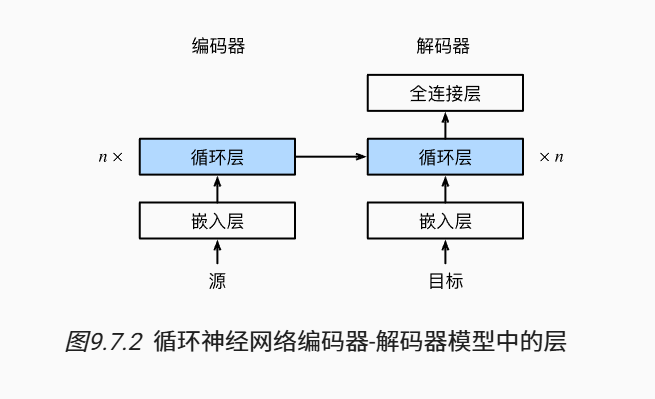

##### ***损失函数***
###### 在每个时间步，解码器预测了输出词元的概率分布，我们可以通过softmax来获取分布，并通过计算交叉熵损失函数来进行优化。而且前文中，我们为了保证批量大小的一致，对序列进行了截断和填充，而填充的部分是填充词元，我们应该将填充词元的预测排除在损失函数的计算之外。
###### 为此，我们可以使用下面的sequence_mask函数通过零值化来屏蔽不相关的项。

In [31]:
def sequence_mask(X, valid_len, value=0):
    """将序列X中大于等于valid_len的位置设为value"""
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None] # 使用None增加维度，使其广播成一个掩码矩阵
    X[~mask] = value # 将True变成False，将False变成True，将True的部分变成value，也就是说将原mask中False的位置变成value
    return X

X = torch.tensor([[1, 2, 3], [4, 5, 6]])
sequence_mask(X, torch.tensor([1, 2]))


tensor([[1, 0, 0],
        [4, 5, 0]])

In [32]:
X = torch.ones(2, 3, 4)
sequence_mask(X, torch.tensor([1, 2]), value=-1)

tensor([[[ 1.,  1.,  1.,  1.],
         [-1., -1., -1., -1.],
         [-1., -1., -1., -1.]],

        [[ 1.,  1.,  1.,  1.],
         [ 1.,  1.,  1.,  1.],
         [-1., -1., -1., -1.]]])

###### 通过将所有词元的损失乘以掩码，以过滤掉损失中填充词元产生的不相关预测。

In [33]:
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带掩码的softmax交叉熵损失函数"""
    # pred的形状为(batch_size, num_steps, vocab_size)
    # label的形状为(batch_size, num_steps)
    # valid_len的形状为(batch_size,)
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label) # 创建一个跟label一样大的矩阵，初始值全为1
        weights = sequence_mask(weights, valid_len) # 将weights中大于等于valid_len的位置设为0
        self.reduction = 'none' # 不进行平均化，因为默认的损失函数会自动把一个Batch里的所有分值求平均
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(pred.permute(0, 2, 1), label) # pytorch的期待输入形状是（batch_size, classes, steps)，而我们的pred的形状是（batch_size, num_steps, vocab_size)，所以这里需要先将pred的维度交换
        weighted_loss = (unweighted_loss * weights).mean(dim=1) # 过滤掉无效损失
        return weighted_loss


In [34]:
loss = MaskedSoftmaxCELoss()
loss(torch.ones(3, 4, 10), torch.ones((3, 4), dtype=torch.long), torch.tensor([4, 2, 0]))

tensor([2.3026, 1.1513, 0.0000])

In [ ]:
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练序列到序列模型"""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])
    
    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[10, num_epochs])

    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0], device=device).reshape(-1, 1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1)
            Y_hat, _ = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            d2l.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))
    print(f'loss{metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f}'
          f'tokens/sec on {str(device)}')

loss 0.019, 8694.4 tokens/sec on cpu


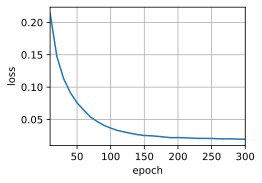

In [36]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 300, d2l.try_gpu()
train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)
encoder = Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqDecoder(len(tgt_vocab), embed_size, num_hiddens,num_layers, dropout)
net = d2l.EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)


##### ***预测序列的评估***
###### 我们可以通过与真实标签序列的对比，评估模型的预测性能。而目前常用的BLEU(Bilingual evaluation understudy)指标，最早是用于评估机器翻译的结果，但现在它已经被广泛用于测量许多应用的输出序列的质量。原则上说，对于预测序列中的任意n元语法（n-grams），BLEU的评估都是这个n元语法是否出现在标签序列中。具体定义如下：
$$exp(\min(0, 1 - \frac{len_{label}}{len_{pred}}))\prod_{n=1}^{k}p_n^{1/2^n},$$
###### 其中，$len_{label}$是标签序列中的词元数，$len_{pred}$是预测序列中的词元数，k是用于匹配的最长的n元语法。$p_n$表示n元语法的精确度， 它是两个数量的比值：第一个是预测序列与标签序列中匹配的n元语法的数量，第二个是预测序列中n元语法的数量的比率。<br>根据BLEU的定义，当预测序列与标签序列完全相同时，BLEU为1，由于n元语法越长，难度越大，所以BLEU为更长的n元语法的精确度分配了更大的权重即，$p_n^{1/2^n}$

In [39]:
#@save
def predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps,
                    device, save_attention_weights=False):
    """序列到序列模型的预测"""
    # 在预测时将net设置为评估模式
    net.eval()
    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [
        src_vocab['<eos>']]
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)
    src_tokens = d2l.truncate_pad(src_tokens, num_steps, src_vocab['<pad>'])
    # 添加批量轴
    enc_X = torch.unsqueeze(
        torch.tensor(src_tokens, dtype=torch.long, device=device), dim=0)
    enc_outputs = net.encoder(enc_X, enc_valid_len)
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)
    # 添加批量轴
    dec_X = torch.unsqueeze(torch.tensor(
        [tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0)
    output_seq, attention_weight_seq = [], []
    for _ in range(num_steps):
        Y, dec_state = net.decoder(dec_X, dec_state)
        # 我们使用具有预测最高可能性的词元，作为解码器在下一时间步的输入
        dec_X = Y.argmax(dim=2)
        pred = dec_X.squeeze(dim=0).type(torch.int32).item()
        # 保存注意力权重（稍后讨论）
        if save_attention_weights:
            attention_weight_seq.append(net.decoder.attention_weights)
        # 一旦序列结束词元被预测，输出序列的生成就完成了
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq)), attention_weight_seq

In [40]:
def bleu(pred_seq, label_seq, k):
    """计算BLEU指标"""
    pred_tokens, label_tokens = pred_seq.split(' '), label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    score = math.exp(min(0, 1 - len_label / len_pred))

    for n in range(1, k+1):
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i:i+n])] += 1
        for i in range(len_pred - n + 1):
            if label_subs[' '.join(pred_tokens[i:i+n])] > 0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i:i+n])] -= 1
        score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    return score


In [41]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, attention_weight_seq = predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device)
    print(f'{eng} => {translation}, bleu {bleu(translation, fra, k=2):.3f}')

go . => va le !, bleu 0.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => il est malade ., bleu 0.658
i'm home . => je suis <unk> ., bleu 0.512
